In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk

import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 2**128

from IPython.display import HTML
from astropy.time import Time
import astropy.units as u
from tqdm import tqdm
from matplotlib import animation
from matplotlib import colors
from matplotlib import patches
from datetime import datetime

from tess_asteroids import MovingTPF
from tess_asteroids.utils import animate_cube, plot_img_aperture

DATADIR = "/Users/jimartin/Work/TESS/tess-asteroid-ml/data"

In [25]:
target = MovingTPF.from_name("2024 YR4", sector=35, camera=1, ccd=4, time_step=0.1)
target

In [26]:
target.get_data(shape=(21,21))
target.reshape_data()
target.time.shape, target.shape

((2578,), (21, 21))

In [27]:
target.background_correction(method="rolling", nframes=101)
target.create_pixel_quality()
# del target.prf_model
target.create_aperture(method="prf", threshold=0.01)

/Users/jimartin/miniforge3/envs/tess/lib/python3.9/site-packages/lkprf/tessprf.py:38: LKPRFWarning: `targets` contains collateral pixels: Column(s) > 2093 
  warnings.warn(
The PRF model contained nans in the last frame (cadence number 2824). The model was replaced with that from the preceding frame (cadence number 2823).


In [28]:
target.animate_tpf(vmin=0, vmax=10, cnorm=False)

In [29]:
[target.quality == 0]

[array([False,  True, False, ...,  True,  True,  True])]

In [37]:
target.corr_flux[target.quality == 0].shape

(2005, 21, 21)

In [38]:
stack = np.nanmedian(target.corr_flux[target.quality == 0], axis=0)

<Axes: xlabel='Pixel Column', ylabel='Pixel Row'>

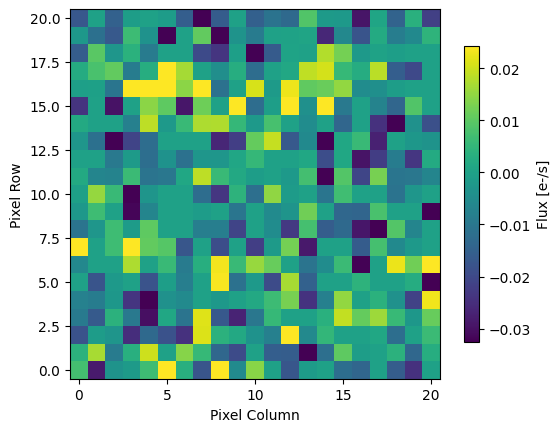

In [39]:
plot_img_aperture(stack)

In [33]:
target.ephem

,sector,camera,ccd,column,row,pixels_per_hour,ra,dec,vmag,sun_distance,obs_distance,phase_angle,time
0,35,1,4,731.244658,255.003517,3.422687,148.856562,4.816340,24.235168,1.559996,0.580838,7.321801,2254.6
1,35,1,4,739.403343,254.335390,3.249115,148.814261,4.835675,24.236320,1.560944,0.581777,7.245335,2254.7
2,35,1,4,747.225712,253.506811,3.074305,148.774097,4.855164,24.237488,1.561892,0.582713,7.170288,2254.8
3,35,1,4,754.716022,252.531497,2.916093,148.736017,4.874746,24.238704,1.562840,0.583639,7.096647,2254.9
4,35,1,4,761.878523,251.423159,2.792317,148.699970,4.894360,24.240000,1.563788,0.584546,7.024400,2255.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,35,1,4,2055.272960,131.459894,1.919419,142.185070,7.834860,25.245598,1.743255,0.775545,10.704348,2274.2
197,35,1,4,2060.377220,130.759674,1.914206,142.160733,7.846638,25.252399,1.744175,0.776731,10.764034,2274.3
198,35,1,4,2065.469993,130.062864,1.908911,142.136456,7.858371,25.259200,1.745094,0.777921,10.823687,2274.4
199,35,1,4,2070.551074,129.369389,1.903539,142.112240,7.870060,25.266000,1.746013,0.779113,10.883300,2274.5
